# Investigating AI Fairness & Bias: Hands-On Analysis with the Adult Dataset

**Purpose:**  
Understand how machine learning models can unintentionally encode societal biases. By the end of this session, you will be able to detect hidden proxies, examine feature influence, and reflect on broader societal implications.


---

### Pre-Session Activity: Breakout Room Discussion

Before diving into the notebook, we will do a **short discussion exercise on fairness**:

- Divide into **at least three teams**.  
- Each team works on **one topic from the breakout room document**:  
  `S3_break_out_rooms_fairness.docx`  
  *(This file contains scenarios and discussion prompts on fairness in promotions, loan approvals, and university admissions.)*  
- Spend **15 minutes** discussing your scenario within your team.  
- After the discussion, we will **return to this notebook** to explore fairness in the *Adult Income* dataset with code and visualizations.

**Discussion Guidelines:**  
- Everyone contributes: observations, questions, and challenges to assumptions.  
- Assign roles: one note-taker, one time-keeper/chair.  
- Consider: which type of fairness matters most? What trade-offs arise?

---

**Core Technical Steps (In-Class):**
- Train a baseline Random Forest classifier.
- Explore group-wise performance metrics to detect disparities.
- Detect proxies for sensitive attributes (`sex`, `race`).
- Examine feature influence using permutation importance.
- Perform counterfactual analysis (how age affects race prediction).

**Extended / Homework Exploration:**
- Classifiers apply thresholds to decide the class. This can impact precision and recall for a given trained classifier. Explore threshold sensitivity and subgroup trade-offs.
- Explore larger subsamples or multi-feature counterfactuals.
- Discuss dataset weights (`fnlwgt`), proxy interpretation, and fairness trade-offs.

**Takeaway:**  
*Through these exercises, you’ll see how technical patterns connect to real-world fairness challenges.*

**Dataset:**  
https://www.openml.org/search?type=data&sort=runs&id=1590&status=active

Iman Mossavat  
Fontys ICT  
2026

## What is Fairness?

Imagine a company uses an AI system to decide who gets promoted. The system looks at past performance data, education, and work history.  

### Scenario: Alice and Bob
Alice and Bob have identical performance scores. Alice gets promoted, Bob doesn’t.  
**Consider:**  
- What might explain this difference?  
- Are there hidden factors that could affect the decision?  
*(There may be multiple explanations, discuss your ideas.)*



### Consider this situation
Suppose gender and race are hidden from decision makers, but **education and zip code predict these attributes**, and they are associated with lower pay.  
**Discuss:**  
- Is it fair if these indirect features influence outcomes?  
- How do hidden correlations create unintended bias?  
- Which features might act as **proxies** for sensitive attributes in real-world decisions?



### Explore “what-if” scenarios
If we only changed a person’s age, education, or another non-sensitive feature, would their promotion outcome change?  
- What does it mean if outcomes change when only one feature is altered?  
- How does this relate to **individual fairness**?  
- Could this reveal hidden dependencies on sensitive attributes?



### Reflect on trade-offs
Suppose we introduce measures to **equalize outcomes across groups**, such as:  
- **Demographic parity:** equal promotion rates across groups  
- **Equal opportunity:** qualified members of each group have equal chances  

**Consider:**  
- How might these measures affect overall system performance?  
- How could group-level fairness influence individual outcomes?  
- Can group fairness and individual fairness conflict? How?


As we explore the Adult dataset, we’ll see how choices in data and modeling can create similar situations in real-world AI systems.

### Some ideas to keep in mind
- **Group fairness:** Equal outcomes across groups  
- **Individual fairness:** Similar individuals treated similarly  
- **Counterfactual fairness:** Changing a sensitive attribute shouldn’t change the outcome  

**Key Point:**  
There is no single global definition of fairness: it depends on context, values, and trade-offs.


In [29]:
# Step 0: Imports & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.inspection import permutation_importance

sns.set(style="whitegrid")

## Exploring the Data: Why It Matters

We are examining the Adult dataset not just to train a predictive model, but also to explore how patterns in data can reflect social structures. Understanding the dataset deeply helps us interpret models responsibly and uncover insights about society.

### Adult Dataset

**Prediction Task:**
We aim to **predict whether a person earns more than $50K per year**.

**Data Source:**

* The dataset comes from the **1994 US Census**, collected by Barry Becker.
* It includes only adults over 16 who have some income and worked more than 0 hours.
* The dataset merges what were originally training and test sets.

**Variables:**

* Most variables are straightforward, such as age, education, and hours worked.
* One variable, **`fnlwgt`**, is special: it is a **weight** that accounts for the fact that some types of people are more or less likely to be included in the survey.

  * Each row represents **one survey respondent**, but not everyone in the US was surveyed.
  * `fnlwgt` indicates **how many real people this row represents**.
  * People with similar backgrounds often have similar weights.
  * Using these weights helps make the sample **more representative of the real population**, but only **within each state**.

**Why Weights Matter:**

* The US population differs across **state, race, age, and Hispanic origin**.
* The Census Bureau provides weights to ensure the dataset **matches real population totals**.
* Think of weights as giving **more influence to underrepresented groups**, helping prevent biased conclusions.
* **Important:** These weights are state-specific and do not adjust for differences across states.

**Reflection Questions:**

* Which columns might indirectly reveal sensitive information like race or sex?
* Why does the Census provide survey weights (`fnlwgt`)?
* What assumptions do we make if we ignore missing values or encode categorical data in certain ways?

In [30]:
# Step 1: Load & Explore Data
data = fetch_openml(name="adult", version=2, as_frame=True)
df = data.frame.copy()

print(f"Dataset shape: {df.shape}")
print("Columns:", list(df.columns))

# Handle missing values: drop rows with any missing value for simplicity
df.replace('?', np.nan, inplace=True)  # '?' is used in Adult dataset for missing
missing = df.isnull().sum()
print("\nMissing values per column:\n", missing[missing > 0])

df.dropna(inplace=True)
print(f"\nDataset shape after dropping missing values: {df.shape}")

sensitive_features = ['sex', 'race']
target = 'class'

Dataset shape: (48842, 15)
Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'class']

Missing values per column:
 workclass         2799
occupation        2809
native-country     857
dtype: int64

Dataset shape after dropping missing values: (45222, 15)


## Subsampling & Encoding: Setting up a playground
We use a small stratified subsample to make experiments fast and interpretable. 
Encoding categorical variables ensures the model can use them, but think about what information might be inadvertently encoded.

**Think About:** 
- Which features are likely to act as proxies for sensitive attributes?
- How does the choice of encoding affect interpretability?


In [28]:
# Step 2: Stratified Subsample
subsample_size = 500
df_small, _ = train_test_split(df, train_size=subsample_size, stratify=df[target], random_state=42)

y = (df_small[target] == ">50K").astype(int)
X = df_small.drop(columns=[target])

# Simple label encoding for categorical features (for in-class demonstration)
from sklearn.preprocessing import LabelEncoder

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
X_encoded = X.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])

print(f"Encoded feature shape: {X_encoded.shape}")


Encoded feature shape: (500, 14)


## Baseline Model: Your first lens on bias
We train a simple Random Forest to establish a performance baseline.

**Reflection Prompt:**
- How does overall accuracy hide group-level disparities?
- What does it mean if the model is good overall but fails systematically for certain groups?


In [31]:
# Step 3: Baseline Model
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

print(f"Baseline Random Forest Accuracy: {model.score(X_test, y_test):.3f}")

Baseline Random Forest Accuracy: 0.830


## Group-wise Performance: Detecting disparities
Here we compare metrics (accuracy, precision, recall) across sensitive groups.

**Questions for Thought:**
- Which groups are advantaged or disadvantaged?
- How might correlations in the data explain these differences?
- What might you do next if you were auditing this model for fairness?


In [32]:
# Step 4: Group-wise Metrics
results = []
for feature in sensitive_features:
    for group in df_small[feature].unique():
        idx = df_small[feature] == group
        y_true = y[idx]
        y_pred_group = model.predict(X_encoded.loc[idx])
        
        results.append({
            'Feature': feature,
            'Group': group,
            'Accuracy': round(accuracy_score(y_true, y_pred_group), 2),
            'Precision': round(precision_score(y_true, y_pred_group), 2),
            'Recall': round(recall_score(y_true, y_pred_group), 2),
            'F1-score': round(f1_score(y_true, y_pred_group), 2)
        })

metrics_df = pd.DataFrame(results)
metrics_df

c:\Users\imanm\.conda\envs\chess_env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\imanm\.conda\envs\chess_env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\imanm\.conda\envs\chess_env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Feature,Group,Accuracy,Precision,Recall,F1-score
0,sex,Male,0.96,0.98,0.91,0.94
1,sex,Female,0.97,1.00,0.69,0.81
2,race,White,0.96,0.98,0.88,0.93
3,race,Black,0.97,1.00,0.83,0.91
4,race,Asian-Pac-Islander,1.00,1.00,1.00,1.00
5,race,Amer-Indian-Eskimo,1.00,1.00,1.00,1.00
6,race,Other,1.00,0.00,0.00,0.00


True or False?

- The model is slightly less able to identify high-income females.
- Small group size results can be extreme and that is misleading

## Proxy Detection: What the model sees
Even if we remove `sex` and `race`, the model might still predict them using other features. These are *proxies*.

**Reflection Prompts:**
- Which features are most predictive of sex or race? Why might that be?
- How could these proxies influence other predictions, like income?
- Are there any surprises in which features act as proxies?


In [33]:
# Step 5: Proxy Detection (Student-friendly version)

from sklearn.preprocessing import LabelEncoder

# Features without sensitive attributes
X_leak = X.drop(columns=['sex','race']).copy()

# Encode categorical features with LabelEncoder
categorical_cols = X_leak.select_dtypes(include=["object", "category"]).columns.tolist()
for col in categorical_cols:
    le = LabelEncoder()
    X_leak[col] = le.fit_transform(X_leak[col])

# Predict sex
y_sex = df_small['sex']
le_sex = LabelEncoder()
y_sex_enc = le_sex.fit_transform(y_sex)

model_sex = RandomForestClassifier(random_state=42)
model_sex.fit(X_leak, y_sex_enc)
y_sex_pred = model_sex.predict(X_leak)
print("Accuracy predicting sex from other features:", accuracy_score(y_sex_enc, y_sex_pred))

# Predict race
y_race = df_small['race']
le_race = LabelEncoder()
y_race_enc = le_race.fit_transform(y_race)

model_race = RandomForestClassifier(random_state=42)
model_race.fit(X_leak, y_race_enc)
y_race_pred = model_race.predict(X_leak)
print("Accuracy predicting race from other features:", accuracy_score(y_race_enc, y_race_pred))

# Top 10 feature importances for predicting sensitive attributes
sex_importances = pd.Series(model_sex.feature_importances_, index=X_leak.columns).sort_values(ascending=False).head(10)
race_importances = pd.Series(model_race.feature_importances_, index=X_leak.columns).sort_values(ascending=False).head(10)

# Combine feature importances into a table
proxy_table = pd.DataFrame({
    'Top Importance for Sex': sex_importances.index,
    'Top Importance for Race': race_importances.index
})

print(proxy_table)


Accuracy predicting sex from other features: 1.0
Accuracy predicting race from other features: 1.0
  Top Importance for Sex Top Importance for Race
0           relationship                  fnlwgt
1                 fnlwgt                     age
2             occupation              occupation
3                    age          hours-per-week
4         marital-status          native-country
5         hours-per-week           education-num
6              education               education
7          education-num            relationship
8              workclass          marital-status
9           capital-gain               workclass


True or False?

- The model is slightly less able to identify high-income females.
- Small group size results can be extreme and that is misleading

## Counterfactual Analysis: Exploring "what-if" scenarios
We simulate changing `age` to see how it affects the predicted probability of race.


We asked the model, ‘If this person were 20 vs 60, would your predicted probability of belonging to each race change?’
We see small but non-zero shifts for some races. This tells us the model is partially relying on age as a proxy, even though age itself shouldn’t determine race.


In [34]:
# Step 6: Counterfactual Analysis 

samples = X_leak.sample(10, random_state=42)

records = []

# Iterate over sample rows and test new ages
for i, row in samples.iterrows():
    preds = {}
    for new_age in [20, 40, 60]:
        modified = row.copy()
        modified['age'] = new_age
        # Keep same column order as training
        pred = model_race.predict_proba(modified.to_frame().T)[0]
        # Map integer classes back to original race names
        preds[new_age] = dict(zip(le_race.inverse_transform(model_race.classes_), pred))
    
    # Compute ΔProb for each race
    for race in le_race.classes_:  # original race names
        delta = preds[60][race] - preds[20][race]
        records.append({
            "Row": i,
            "Race": race,
            "Prob(20)": preds[20][race],
            "Prob(60)": preds[60][race],
            "ΔProb (60-20)": delta
        })

df_age_effect = pd.DataFrame(records)

# Show mean ΔProb per race
print(df_age_effect.groupby("Race")["ΔProb (60-20)"].mean().round(3))


Race
Amer-Indian-Eskimo   -0.012
Asian-Pac-Islander    0.003
Black                 0.023
Other                -0.014
White                 0.000
Name: ΔProb (60-20), dtype: float64


# Understanding Thresholds, Precision, and Recall (Minimal Introduction)

When a model predicts a probability (like the chance someone earns >50K), we need to **decide at what probability we call it a “yes”**.  
This is called the **decision threshold**.

- **Lower threshold (e.g., 0.3):** More people labeled as positive → higher recall, lower precision.
- **Higher threshold (e.g., 0.7):** Fewer people labeled as positive → higher precision, lower recall.

**Precision:** Of all predicted positives, how many were correct?  
**Recall:** Of all actual positives, how many did we catch?

> For fairness, thresholds matter because some groups may benefit or suffer more depending on where we draw the line.

## **Threshold Sensitivity: Decisions under Uncertainty**

We test different classification thresholds to see how **group-level performance shifts**.

When a model predicts probabilities (e.g., the chance someone earns >50K), we need to **choose a cutoff — the threshold —** to turn probabilities into a yes/no decision.

* **Lower threshold** (e.g., 0.3): more people are labeled positive → more true positives, but also more false positives.
* **Higher threshold** (e.g., 0.7): stricter → fewer false positives, but some true positives are missed.

By experimenting with thresholds, we can see **who benefits or suffers**. Some groups (like females or small racial categories) are **more sensitive to threshold changes**, revealing hidden disparities in the model.

> Threshold tuning has **real fairness implications**.

---

### **Reflective Questions**

* How do small changes in threshold affect different groups?
* Which groups are most sensitive, and why?
* How does this connect to **fairness trade-offs** in real systems?
* What **system-level or societal factors** could explain these patterns?

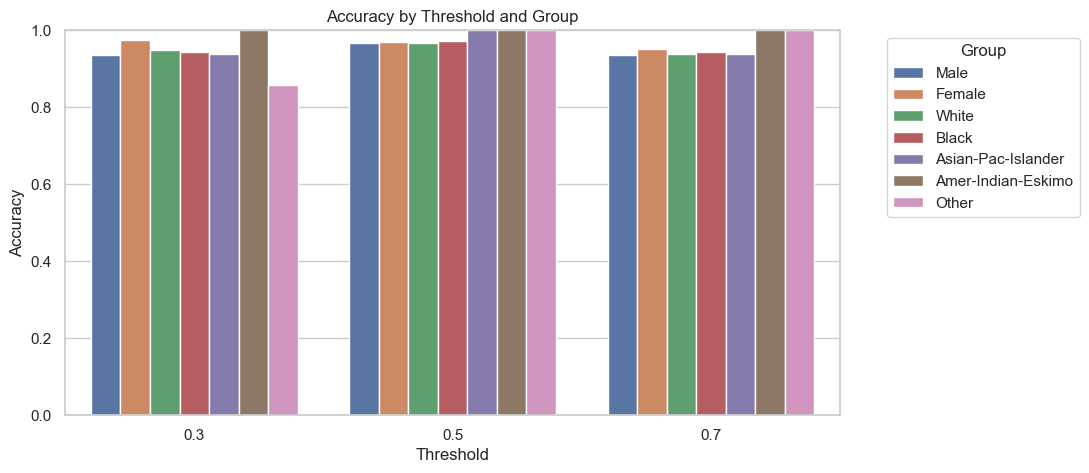

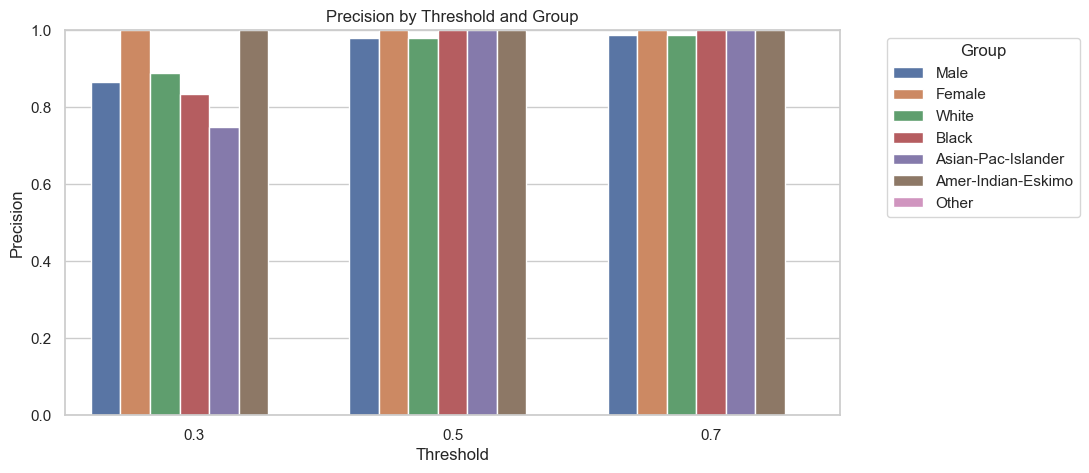

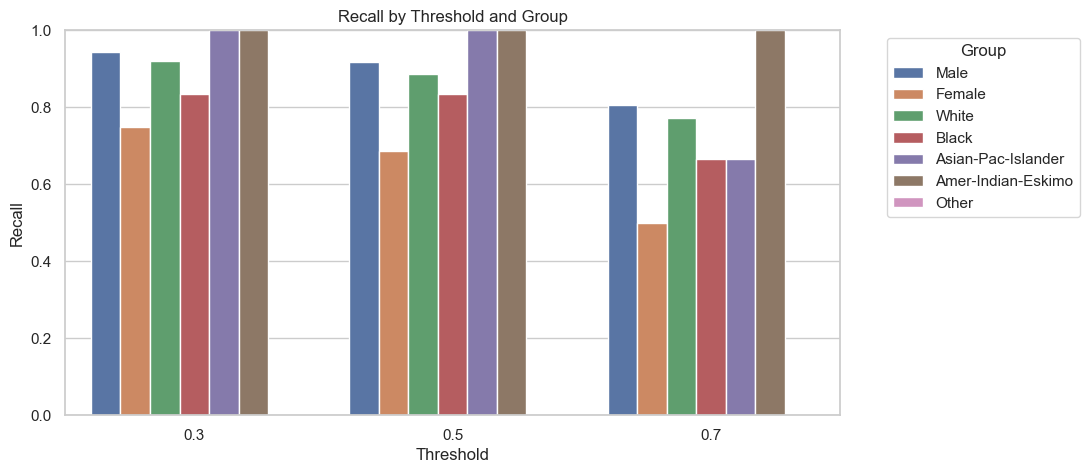

In [35]:

# Step 7: Threshold Sensitivity - collect metrics
thresholds = [0.3, 0.5, 0.7]
records = []

for t in thresholds:
    y_pred_thresh = (model.predict_proba(X_encoded)[:,1] >= t).astype(int)
    for feature in sensitive_features:
        for group in df_small[feature].unique():
            idx = df_small[feature] == group
            acc = accuracy_score(y[idx], y_pred_thresh[idx])
            prec = precision_score(y[idx], y_pred_thresh[idx], zero_division=0)
            rec = recall_score(y[idx], y_pred_thresh[idx], zero_division=0)
            records.append({
                'Threshold': t,
                'Feature': feature,
                'Group': group,
                'Accuracy': acc,
                'Precision': prec,
                'Recall': rec
            })

df_metrics = pd.DataFrame(records)

# Melt for plotting
df_melt = df_metrics.melt(
    id_vars=['Threshold', 'Feature', 'Group'],
    value_vars=['Accuracy', 'Precision', 'Recall'],
    var_name='Metric',
    value_name='Score'
)

# Plot bar plots
sns.set(style="whitegrid")
metrics = ['Accuracy', 'Precision', 'Recall']

for metric in metrics:
    plt.figure(figsize=(10,5))
    sns.barplot(
        data=df_melt[df_melt['Metric']==metric],
        x='Threshold', y='Score', hue='Group'
    )
    plt.title(f'{metric} by Threshold and Group')
    plt.ylim(0,1)
    plt.ylabel(metric)
    plt.xlabel('Threshold')
    plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()


## Predicted Probabilities for Actual Positives

We focus on **people who actually earned >50K** (the positive class).  
By looking at the predicted probabilities for these individuals, we can see:

- Which groups the model is more confident about  
- Which groups the model may systematically under- or over-predict  

This helps reveal **hidden disparities** even when overall accuracy looks good.

**Reflective Questions:**

- Are some groups consistently predicted with higher or lower probabilities?  
- How could this affect fairness if we use a probability threshold to make decisions?  
- How do these patterns relate to the threshold sensitivity plots we saw earlier?


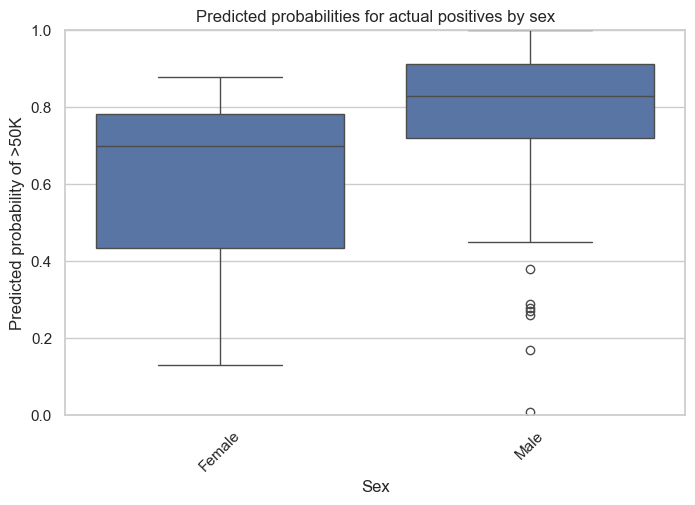

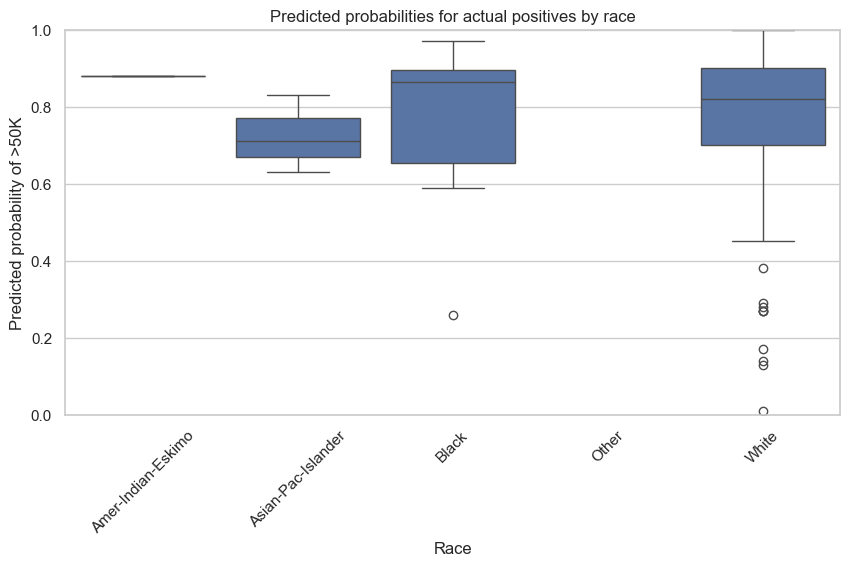

In [36]:
# Select only actual positives
idx_pos = y == 1
probs_pos = model.predict_proba(X_encoded.loc[idx_pos])[:,1]
groups_pos_sex = df_small.loc[idx_pos, 'sex']
groups_pos_race = df_small.loc[idx_pos, 'race']


sns.set(style="whitegrid")

# Boxplot by sex
plt.figure(figsize=(8,5))
sns.boxplot(x=groups_pos_sex, y=probs_pos)
plt.ylabel("Predicted probability of >50K")
plt.xlabel("Sex")
plt.title("Predicted probabilities for actual positives by sex")
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.show()

# Boxplot by race
plt.figure(figsize=(10,5))
sns.boxplot(x=groups_pos_race, y=probs_pos)
plt.ylabel("Predicted probability of >50K")
plt.xlabel("Race")
plt.title("Predicted probabilities for actual positives by race")
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.show()


# Homework / Extended Analysis
1. Larger subsamples to see stability of metrics.
2. Loop over all intersectional subgroups (sex x race).
3. Multi-feature counterfactuals (age + education).
4. Conditional permutation importance.
5. Effects of removing vs keeping sensitive features.
6. Extended thresholds (0.1–0.9).
7. Reflect on ethical implications and write a short report connecting proxy detection, counterfactuals, thresholds to societal impacts.
8. What does the code below do?


In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(X_train, y_train, sample_weight=X_train['fnlwgt'])